# RiMEA 13: Fundamental Diagram on Stairs

This notebook approximates RiMEA Test 13 with a zone-based stair model. The stair segment is represented by a slowdown zone inside the corridor. Agents keep a shared flat-ground demographic around $1.2\,\mathrm{m/s}$, while the stair behavior is introduced through zone speed factors `0.5` for `upwards` and `0.7` for `downwards`.

The outputs focus on three questions:

- do the `upstairs` and `downstairs` speed-density points stay within the Corbetta spread?
- is the `downstairs` curve faster than the `upstairs` curve at the same density?
- what do the trajectories look like in the stair geometry?

In [1]:
import json
import tempfile
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pedpy
from shapely.geometry import Point, Polygon

from core.rimea13_stairs import (
    EXIT_COORDINATES,
    FRUIN_STAIR_SPEEDS,
    RIEMA_STANDARD_DEMOGRAPHIC,
    STAIR_WALKABLE_AREA_WKT,
    STAIR_ZONE_COORDINATES,
    STAIR_ZONE_SPEED_FACTORS,
    build_raw_scenario,
    corbetta_envelope_bounds,
)
from core.scenario import load_scenario, run_scenario


In [2]:
plt.rcParams.update(
    {
        "figure.facecolor": "white",
        "axes.facecolor": "#f8fafc",
        "axes.edgecolor": "#334155",
        "axes.labelcolor": "#0f172a",
        "axes.titleweight": "bold",
        "xtick.color": "#0f172a",
        "ytick.color": "#0f172a",
        "font.size": 11,
    }
)

STAIR_ZONE = Polygon(STAIR_ZONE_COORDINATES)
COLORS = {"up": "#2563EB", "down": "#DC2626"}


## Build and Run Both Scenarios

In [3]:
def run_direction(direction: str):
    raw = build_raw_scenario(direction=direction)
    tmpdir = tempfile.TemporaryDirectory()
    scenario_dir = Path(tmpdir.name)
    (scenario_dir / "config.json").write_text(json.dumps(raw, indent=2), encoding="utf-8")
    (scenario_dir / "geometry.wkt").write_text(STAIR_WALKABLE_AREA_WKT, encoding="utf-8")

    scenario = load_scenario(str(scenario_dir))
    result = run_scenario(scenario, seed=42)
    traj_df = result.trajectory_dataframe()[["id", "frame", "x", "y"]].copy()
    traj = pedpy.TrajectoryData(traj_df, frame_rate=result.frame_rate)
    speed_df = pedpy.compute_individual_speed(
        traj_data=traj,
        frame_step=10,
        speed_calculation=pedpy.SpeedCalculation.BORDER_EXCLUDE,
    )
    merged = traj.data.merge(speed_df[["id", "frame", "speed"]], on=["id", "frame"], how="inner")
    stair_points = merged[
        merged.apply(lambda row: STAIR_ZONE.covers(Point(row["x"], row["y"])), axis=1)
    ].copy()
    frame_counts = stair_points.groupby("frame")["id"].nunique().rename("count")
    stair_points = stair_points.merge(frame_counts, on="frame", how="left")
    stair_points["density"] = stair_points["count"] / STAIR_ZONE.area
    stair_points = stair_points[(stair_points["density"] >= 0.6) & (stair_points["density"] <= 1.5)]
    stair_points["density_bin"] = np.round(stair_points["density"], 1)
    return {
        "direction": direction,
        "scenario": scenario,
        "result": result,
        "traj": traj,
        "walkable_area": pedpy.WalkableArea(scenario.walkable_polygon),
        "stair_points": stair_points,
        "tmpdir": tmpdir,
    }


In [4]:
%%capture
up = run_direction("up")
down = run_direction("down")


In [5]:
summary = pd.DataFrame(
    [
        {
            "direction": run["direction"],
            "zone_speed_factor": STAIR_ZONE_SPEED_FACTORS[run["direction"]],
            "evacuation_time [s]": run["result"].evacuation_time,
            "stair samples": len(run["stair_points"]),
            "mean stair speed [m/s]": run["stair_points"]["speed"].mean(),
        }
        for run in [up, down]
    ]
)
summary


,direction,zone_speed_factor,evacuation_time [s],stair samples,mean stair speed [m/s]
0,up,0.5,46.88,639,0.477955
1,down,0.7,43.20,546,0.633789


## Geometry, Stair Zone, and Trajectories

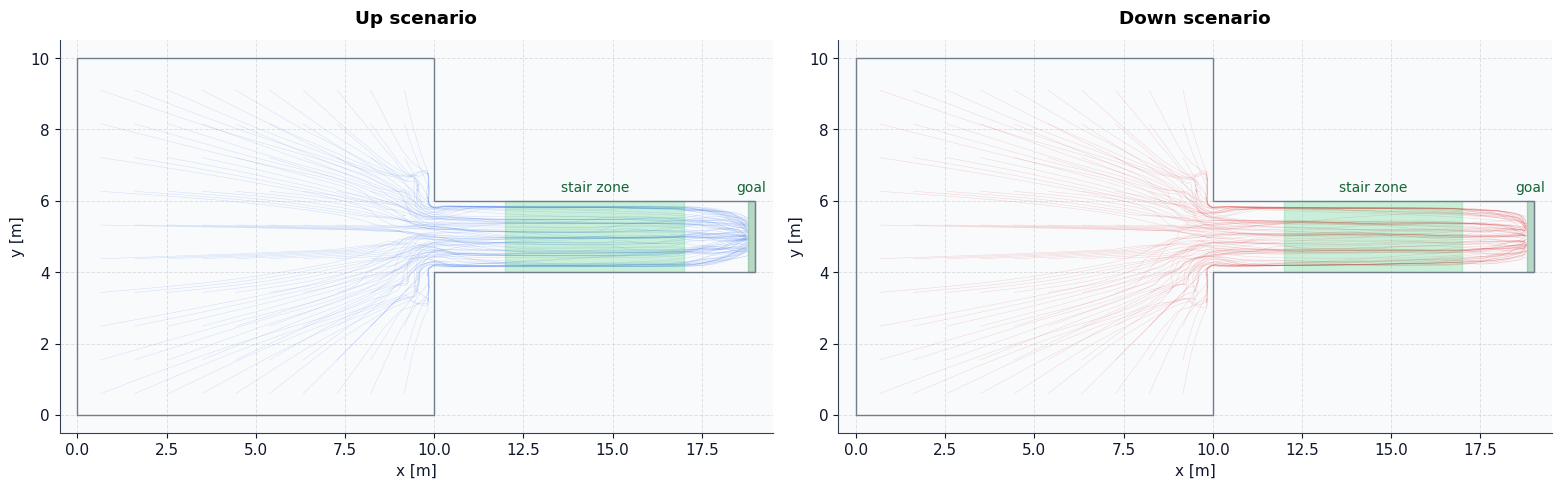

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(15.5, 5.4), constrained_layout=True)

for ax, run in zip(axes, [up, down]):
    pedpy.plot_trajectories(
        traj=run["traj"],
        walkable_area=run["walkable_area"],
        axes=ax,
        traj_alpha=0.18,
        traj_width=0.35,
        traj_color=COLORS[run["direction"]],
    ).set_aspect("equal")
    ax.fill(
        [xy[0] for xy in STAIR_ZONE_COORDINATES],
        [xy[1] for xy in STAIR_ZONE_COORDINATES],
        color="#22C55E",
        alpha=0.22,
        zorder=2,
    )
    ax.fill(
        [xy[0] for xy in EXIT_COORDINATES],
        [xy[1] for xy in EXIT_COORDINATES],
        color="#15803D",
        alpha=0.28,
        zorder=2,
    )
    ax.text(14.5, 6.25, "stair zone", color="#166534", fontsize=10, ha="center")
    ax.text(18.9, 6.25, "goal", color="#166534", fontsize=10, ha="center")
    ax.set_title(f"{run['direction'].title()} scenario", pad=12)
    ax.set_xlim(-0.5, 19.5)
    ax.set_ylim(-0.5, 10.5)
    ax.set_xlabel("x [m]")
    ax.set_ylabel("y [m]")
    ax.grid(True, linestyle="--", linewidth=0.7, alpha=0.35)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.show()

## Fundamental Diagram Against the Corbetta Spread

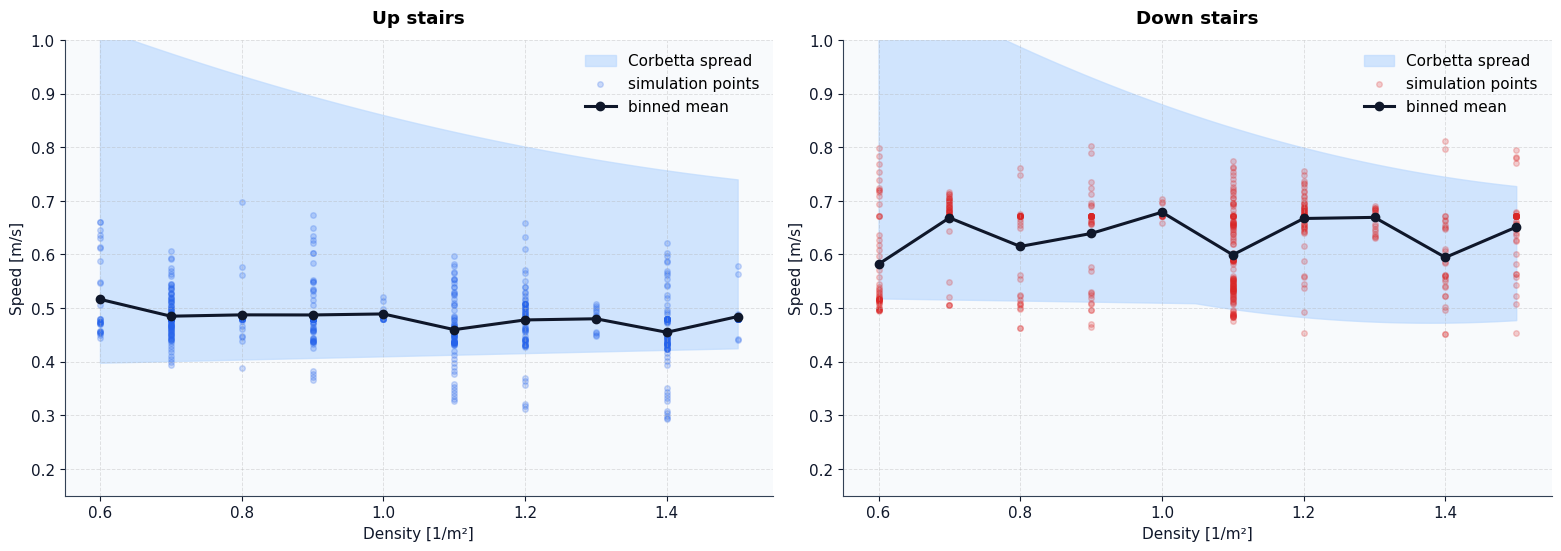

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(15.5, 5.4), constrained_layout=True)

for ax, run in zip(axes, [up, down]):
    rho = np.linspace(0.6, 1.5, 400)
    low, high = corbetta_envelope_bounds(run["direction"], rho)
    ax.fill_between(rho, low, high, color="#BFDBFE", alpha=0.7, label="Corbetta spread")
    ax.scatter(
        run["stair_points"]["density"],
        run["stair_points"]["speed"],
        s=16,
        alpha=0.22,
        color=COLORS[run["direction"]],
        label="simulation points",
    )
    binned = run["stair_points"].groupby("density_bin", observed=True)["speed"].mean()
    ax.plot(binned.index.to_numpy(dtype=float), binned.to_numpy(), color="#0F172A", linewidth=2.2, marker="o", label="binned mean")
    ax.set_title(f"{run['direction'].title()} stairs", pad=12)
    ax.set_xlabel("Density [1/m²]")
    ax.set_ylabel("Speed [m/s]")
    ax.set_xlim(0.55, 1.55)
    ax.set_ylim(0.15, 1.0)
    ax.grid(True, linestyle="--", linewidth=0.7, alpha=0.35)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.legend(frameon=False)

plt.show()

## Density-Matched Comparison

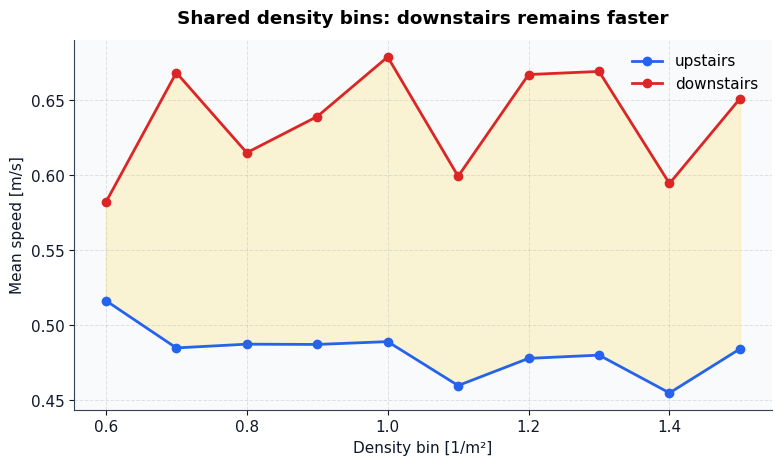

,density_bin,upstairs_speed,downstairs_speed,difference
0,0.6,0.516390,0.581952,0.065562
1,0.7,0.484855,0.668359,0.183504
2,0.8,0.487344,0.614976,0.127633
3,0.9,0.487162,0.639108,0.151946
4,1.0,0.489050,0.678834,0.189784
5,1.1,0.459767,0.599267,0.139500
6,1.2,0.477881,0.667097,0.189216
7,1.3,0.480040,0.669163,0.189124
8,1.4,0.454843,0.594457,0.139613
9,1.5,0.484194,0.651007,0.166813


In [8]:
up_binned = up["stair_points"].groupby("density_bin", observed=True)["speed"].mean()
down_binned = down["stair_points"].groupby("density_bin", observed=True)["speed"].mean()
common_bins = up_binned.index.intersection(down_binned.index)
comparison = pd.DataFrame(
    {
        "density_bin": common_bins.astype(float),
        "upstairs_speed": up_binned.loc[common_bins].to_numpy(),
        "downstairs_speed": down_binned.loc[common_bins].to_numpy(),
    }
)
comparison["difference"] = comparison["downstairs_speed"] - comparison["upstairs_speed"]

fig, ax = plt.subplots(figsize=(9, 4.8))
ax.plot(comparison["density_bin"], comparison["upstairs_speed"], color=COLORS["up"], marker="o", linewidth=2.0, label="upstairs")
ax.plot(comparison["density_bin"], comparison["downstairs_speed"], color=COLORS["down"], marker="o", linewidth=2.0, label="downstairs")
ax.fill_between(
    comparison["density_bin"],
    comparison["upstairs_speed"],
    comparison["downstairs_speed"],
    color="#FDE68A",
    alpha=0.35,
)
ax.set_title("Shared density bins: downstairs remains faster", pad=12)
ax.set_xlabel("Density bin [1/m²]")
ax.set_ylabel("Mean speed [m/s]")
ax.grid(True, linestyle="--", linewidth=0.7, alpha=0.35)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(frameon=False)
plt.show()

comparison

## Flat-Ground Demographic `v0` Used In Both Scenarios

In [9]:
pd.DataFrame(RIEMA_STANDARD_DEMOGRAPHIC)

,label,count,v0
0,under_30_internal,15,1.34
1,under_30_external,15,1.30
2,age_30_50_internal,15,1.24
3,age_30_50_external,15,1.20
4,over_50_internal,15,1.14
5,over_50_external,15,1.10
6,impaired_mobility,10,0.96


## Fruin Stair-Speed Reference Used To Motivate The Zone Factors

In [10]:
pd.DataFrame(
    [
        {
            "direction": direction,
            "group": row["label"],
            "stair_speed": row["speed"],
        }
        for direction, rows in FRUIN_STAIR_SPEEDS.items()
        for row in rows
    ]
)

,direction,group,stair_speed
0,down,under_30_internal,0.76
1,down,under_30_external,0.81
2,down,age_30_50_internal,0.65
3,down,age_30_50_external,0.78
4,down,over_50_internal,0.55
5,down,over_50_external,0.59
6,down,impaired_mobility,0.42
7,up,under_30_internal,0.55
8,up,under_30_external,0.58
9,up,age_30_50_internal,0.50


In [11]:
for run in [up, down]:
    run["result"].cleanup()
    run["tmpdir"].cleanup()